In [18]:
import sys
import os
import pandas as pd

sys.path.append(os.path.abspath(".."))

In [19]:
!pip install statsmodels


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf

plt.style.use("ggplot")

In [21]:
sales = pd.read_csv(
    "../data/raw/sales_train_evaluation.csv"
)

calendar = pd.read_csv(
    "../data/raw/calendar.csv"
)

print(sales.shape)
print(calendar.shape)

(30490, 1947)
(1969, 14)


In [22]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [68]:
item = sales.iloc[0]

In [69]:
sales_cols = [
    c
    for c in sales.columns
    if c.startswith("d_")
]

len(sales_cols)

1941

In [70]:
demand = pd.DataFrame(
    {
        "d": sales_cols,
        "demand": item[sales_cols].values
    }
)

demand.head()

,d,demand
0,d_1,0
1,d_2,0
2,d_3,0
3,d_4,0
4,d_5,0


In [71]:
demand = demand.merge(
    calendar,
    on="d",
    how="left"
)

demand.head()

,d,demand,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,d_2,0,2011-01-30,11101,Sunday,2,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,d_3,0,2011-01-31,11101,Monday,3,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,d_4,0,2011-02-01,11101,Tuesday,4,2,2011,NaN,NaN,NaN,NaN,1,1,0
4,d_5,0,2011-02-02,11101,Wednesday,5,2,2011,NaN,NaN,NaN,NaN,1,0,1


In [72]:
demand["date"] = pd.to_datetime(
    demand["date"]
)

In [73]:
print(
    "Mean:",
    demand["demand"].mean()
)

print(
    "Std:",
    demand["demand"].std()
)

print(
    "Max:",
    demand["demand"].max()
)

print(
    "Min:",
    demand["demand"].min()
)

Mean: 0.3261205564142195
Std: 0.7080413261097673
Max: 5
Min: 0


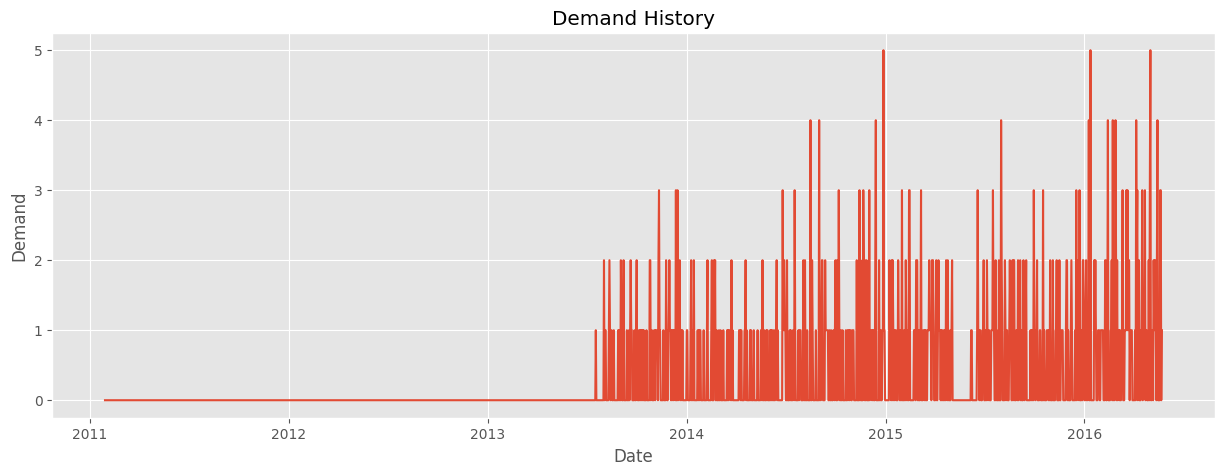

In [74]:
plt.figure(figsize=(15,5))

plt.plot(
    demand["date"],
    demand["demand"]
)

plt.title(
    "Demand History"
)

plt.xlabel("Date")

plt.ylabel("Demand")

plt.show()

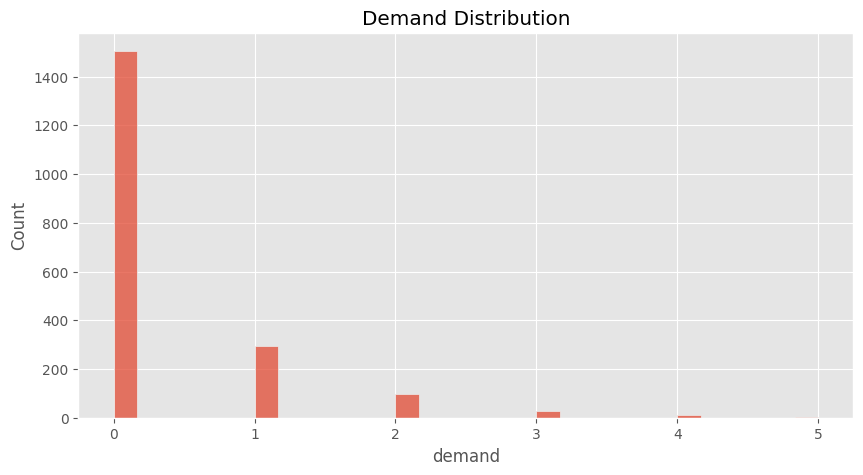

In [75]:
plt.figure(figsize=(10,5))

sns.histplot(
    demand["demand"],
    bins=30
)

plt.title(
    "Demand Distribution"
)

plt.show()

In [76]:
weekday_avg = (
    demand
    .groupby("weekday")
    ["demand"]
    .mean()
    .sort_values(
        ascending=False
    )
)

weekday_avg

weekday
Saturday      0.47482
Tuesday      0.353791
Sunday       0.352518
Friday       0.310469
Monday       0.288809
Thursday     0.256318
Wednesday    0.245487
Name: demand, dtype: object

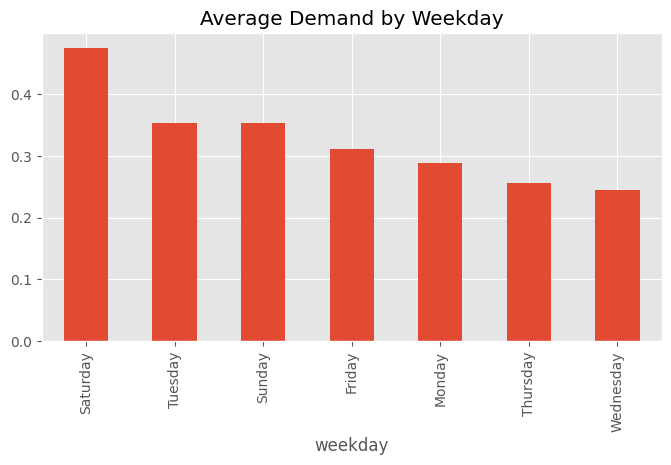

In [77]:
weekday_avg.plot(
    kind="bar",
    figsize=(8,4)
)

plt.title(
    "Average Demand by Weekday"
)

plt.show()

In [78]:
month_avg = (
    demand
    .groupby("month")
    ["demand"]
    .mean()
)

month_avg

month
1      0.35443
2     0.364706
3     0.344086
4     0.338889
5     0.231638
6     0.213333
7     0.225806
8     0.329032
9     0.373333
10    0.322581
11        0.38
12     0.43871
Name: demand, dtype: object

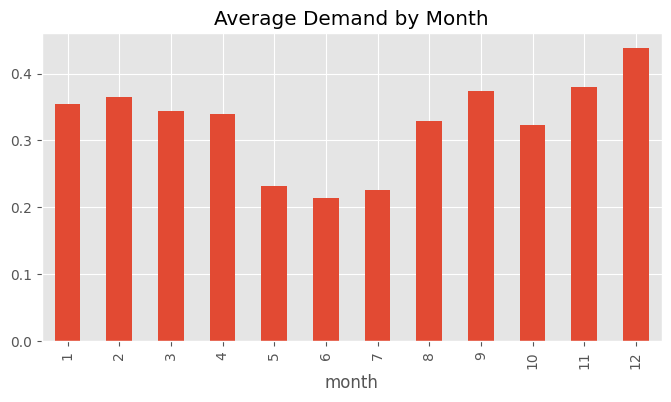

In [ ]:
month_avg.plot(
    kind="bar",
    figsize=(8,4)
)

plt.title(
    "Average Demand by Month"
)

plt.show()

<Figure size 1200x500 with 0 Axes>

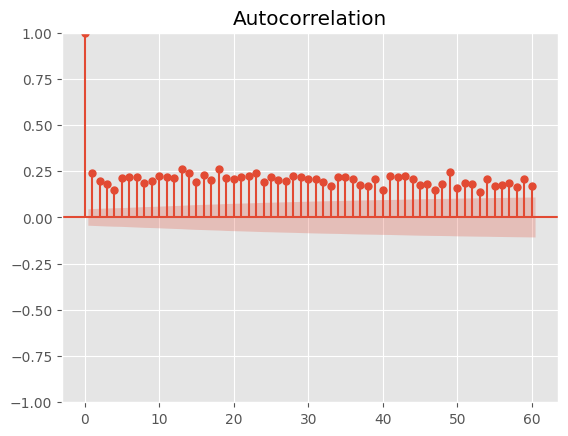

In [80]:
plt.figure(figsize=(12,5))

plot_acf(
    demand["demand"],
    lags=60
)

plt.show()

In [81]:
demand["rolling_7"] = (
    demand["demand"]
    .rolling(7)
    .mean()
)

demand["rolling_28"] = (
    demand["demand"]
    .rolling(28)
    .mean()
)

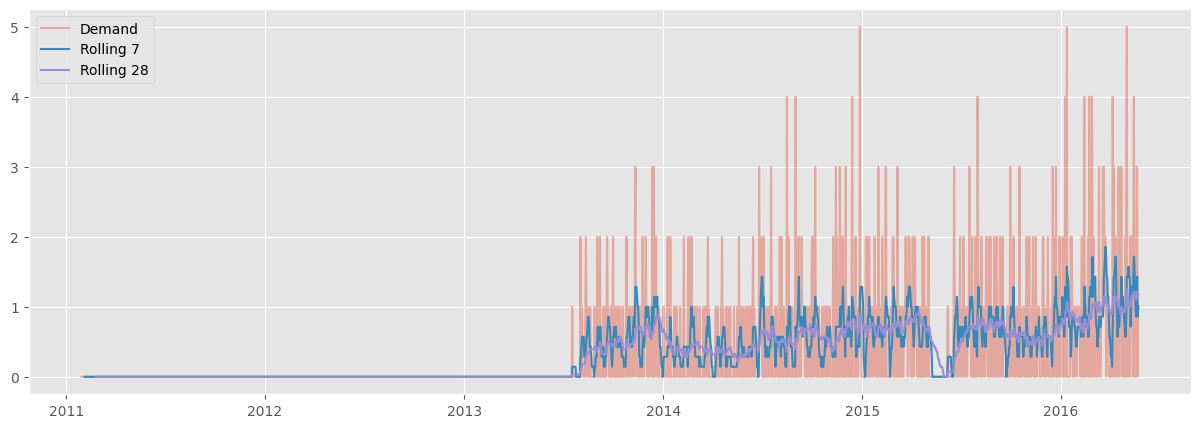

In [82]:
plt.figure(figsize=(15,5))

plt.plot(
    demand["date"],
    demand["demand"],
    alpha=0.4
)

plt.plot(
    demand["date"],
    demand["rolling_7"]
)

plt.plot(
    demand["date"],
    demand["rolling_28"]
)

plt.legend(
    [
        "Demand",
        "Rolling 7",
        "Rolling 28"
    ]
)

plt.show()